In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap, Normalize
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import torch
import dnnlib.util_v5 as util
from tqdm import tqdm
import pickle
from matplotlib.ticker import FuncFormatter
import gc
from PIL import Image

import numpy as np
import pickle
import os
import re 
import json 
import click
import torch
from torch_utils import distributed as dist
from training import toy_training_loop_vfm_noDataGen
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import colors
from plot_neural import *
from plot_sim_results_v7 import *
from plot_sim_results_img_v7 import * 
# from plot_musal_v5 import * 
import pickle, types
from torch_utils import persistence

import pandas as pd

import warnings
warnings.filterwarnings('ignore', 'Grad strides do not match bucket view strides') # False warning 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
colorgrad = "PuOr"

In [2]:
def plot_tau(T, out_imgs_tau, dset_samples, trial_idx, tau, title=None):
    # Plot True
    plot_frame(dset_samples, T, trial_idx)
    plt.suptitle(f'true, trial = {trial_idx}')
    plt.subplots_adjust(bottom=0.2)  # Make room for horizontal colorbar

    # Plot Simulated
    plot_frame(out_imgs_tau, T, trial_idx)
    if title is None:
        plt.suptitle(f'simulated- tau = {tau}')
    else:
        plt.suptitle(title)
    plt.subplots_adjust(bottom=0.2)

In [3]:
def recon_check_x0(encoder, trial_check, T_check, dset_samples):
    encoder = encoder.to(device).eval()
    X1_ori = dset_samples[trial_check][T_check,0,:,:]
    data_flattent = [np.reshape(a, (a.shape[0], -1), order='C') for a in dset_samples]
    with torch.inference_mode():
        X1 = torch.from_numpy(data_flattent[trial_check][T_check,:]).to(device=device, dtype=torch.float32)
        X0 = encoder.rsample(X1)
    X0_back = X0.reshape(X0.shape[0], C, H, W)
    return X0_back[0,0,:,:].detach().cpu().numpy()

In [4]:
def recon_check_x0_allT(encoder, trial_check, dset_samples):
    encoder = encoder.to(device).eval()
    X1_ori = dset_samples[trial_check][T_check,0,:,:]
    data_flattent = [np.reshape(a, (a.shape[0], -1), order='C') for a in dset_samples]
    with torch.inference_mode():
        X1 = torch.from_numpy(data_flattent[trial_check]).to(device=device, dtype=torch.float32)
        X0 = encoder.rsample(X1)
    X0_back = X0.reshape(X0.shape[0], C, H, W)
    return X0_back.detach().cpu().numpy()

# 1. Read Data

In [5]:
folder_data = 'out/bird_song_local/dimk_lag8_ori/t/none/data'
dataset_samples = np.load(folder_data + "/dataset_samples.npz", allow_pickle=True)
cov_static_samples = np.load(folder_data + "/cov_static_trunc_only.npz", allow_pickle=True)

dset_samples = to_list_of_arrays(dataset_samples['samples'])
cov_stat_samples = to_list_of_arrays(cov_static_samples['samples'])
# mean_img = np.load('data/musal_behavior/mean_image.npy')

(26, 1, 64, 64)


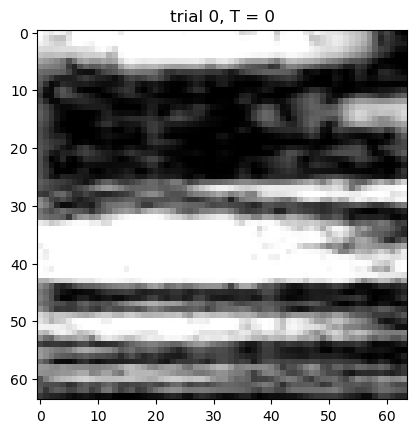

In [6]:
idx = 0
plt.imshow(dset_samples[0][idx,0], cmap = 'gray')
plt.title('trial 0, T = ' + str(idx));
print(dset_samples[0].shape)

In [7]:
eps = 1e-1
T_max = max(a.shape[0] for a in dset_samples)
padded = [np.pad(a, ((0, T_max-a.shape[0]), (0,0), (0,0), (0,0)), mode='constant', constant_values=np.nan)
          for a in dset_samples]                                              # -> (n_trial, T_max, C, H, W)
stacked = np.stack(padded, axis=0)
min_img = np.nanmin(stacked, axis=(0,1))                                      # shape (C,H,W)
max_img = np.nanmax(stacked, axis=(0,1))                                      # shape (C,H,W)
clamp_range = np.stack([min_img - eps, max_img + eps], axis=0).astype(np.float32)  # shape (2,C,H,W)

# 2. Read Model

In [8]:
folder = 'out/bird_song_local/dimk_lag8_ori/t/none/00000-bird_dim50_lag8_none-prr-uncond-regularFM-gpus1-batch256-fp32'
chk_pts = '/network-snapshot-067737.pkl'
useCov = False
dim_to_keep = 3

pkl_path = folder + chk_pts

In [9]:
if not hasattr(persistence, "_orig_reconstruct"):
    persistence._orig_reconstruct = persistence._reconstruct_persistent_obj
def _tolerant_reconstruct(meta):
    try:
        return persistence._orig_reconstruct(meta)
    except Exception:
        class _Stub: pass
        return _Stub()

class PatchedUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == "torch_utils.persistence" and name == "_reconstruct_persistent_obj":
            return _tolerant_reconstruct
        return super().find_class(module, name)

with open(pkl_path, "rb") as f:
    model_all = PatchedUnpickler(f).load()

# use the net; ignore any loss_fn in the pickle
net = model_all["ema"] if "ema" in model_all else model_all["net"]
flow_net = net.unet_model
dyn_net   = net.vnet_model
encoder   = net.encoder

In [10]:
lag = infer_lag_k_from_dyn_net(dyn_net)

In [11]:
lag

8

# 3. Check Encoder

In [12]:
is_image = (np.asarray(dset_samples[0]).ndim == 4)
if is_image:
    _, C, H, W = np.asarray(dset_samples[0]).shape
T_min = min(arr.shape[0] for arr in dset_samples)
T_max = max(arr.shape[0] for arr in dset_samples)
n_step = T_max
dset_samples_look = dset_samples
# del dset_samples

In [13]:
print(T_max)

133


In [14]:
print("k_max =", encoder.k_max, "use_pop_stats =", encoder.use_pop_stats)

k_max = 200 use_pop_stats = True


In [15]:
trial_check = 10
T_check = 0
X0_back = recon_check_x0(encoder, trial_check, T_check, dset_samples = dset_samples_look)

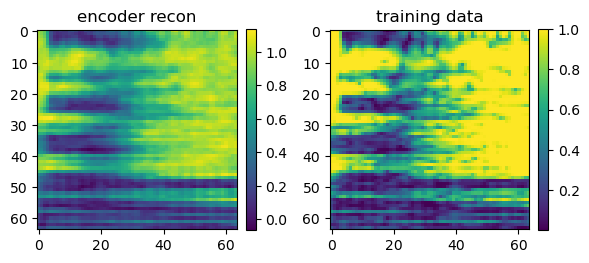

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(6, 5))

im1 = axs[0].imshow(X0_back)
fig.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04)  # smaller, aligned
axs[0].set_title('encoder recon')

im2 = axs[1].imshow(dset_samples_look[trial_check][T_check,0,:,:])
fig.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04)  # same settings
axs[1].set_title('training data')

plt.tight_layout()
plt.show()

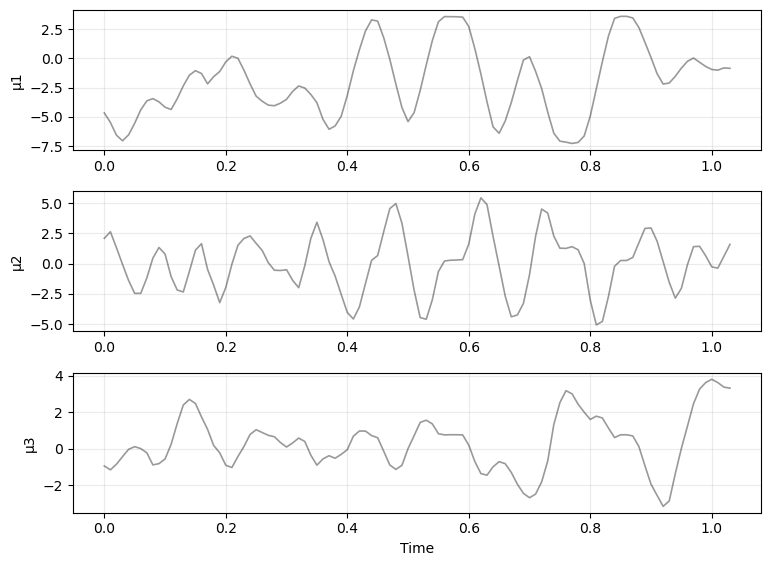

In [17]:
data_flattent = [np.reshape(a, (a.shape[0], -1), order='C') for a in dset_samples_look]
dim_to_keep = 3
mu_keep = get_mu_from_encoder(encoder, data_flattent, dim_to_keep, trial_check)
plot_latent_time_series([mu_keep], alpha = 0.4, dims=np.arange(dim_to_keep), 
                        dt=0.01, labels=None)

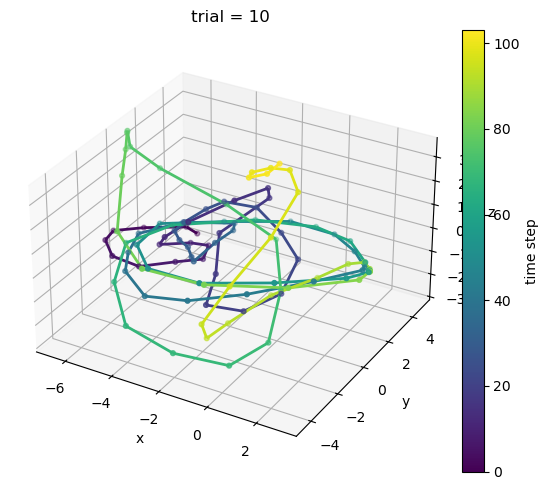

In [18]:
plot_traj_3d(mu_keep, title = 'trial = ' + str(trial_check))

In [19]:
mu_tmp, d, L, loading, bias = latent_mu(dset_samples_look, encoder.to(device), dim_to_keep, device, fullRes = True)
L_np = L.detach().cpu().numpy()
d_np = d.detach().cpu().numpy()
loading_np = loading.detach().cpu().numpy()
mu_all = get_mu_from_encoder(encoder, data_flattent, 64*64, 0)

In [20]:
k_max = 200
k_target = 50
loading_norm_all = torch.norm(loading[:,0:k_max], dim= 0).detach().cpu().numpy()
energy = loading_norm_all ** 2 
cum_energy = np.cumsum(energy)
K_eff = 1 + np.searchsorted(cum_energy, 0.95 * cum_energy[-1])

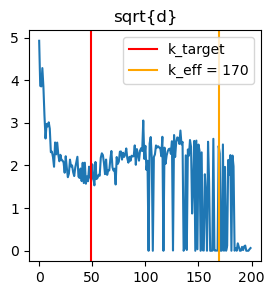

In [21]:
fig = plt.figure(figsize=(3, 3))
plt.plot(np.sqrt(d_np[0:k_max]))
plt.axvline(x=k_target-1, color='red', label = 'k_target')
plt.axvline(x=K_eff-1, color='orange', label = 'k_eff = ' + str(K_eff))
plt.title('sqrt{d}');
plt.legend()

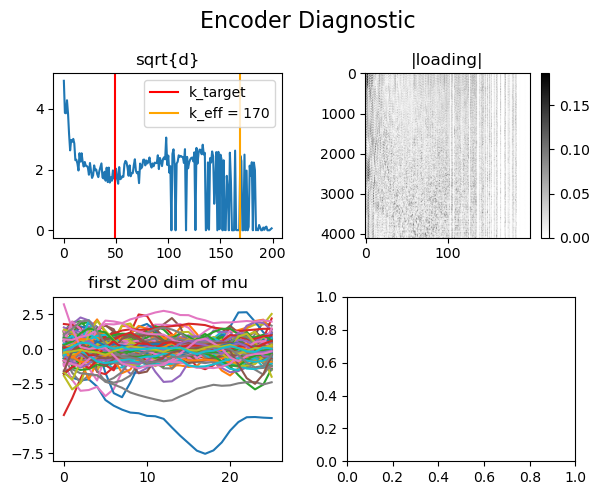

In [22]:
k_max = 200
dim_check_most = 200
k_target = 50
rows = loading.shape[0]
cols = dim_check_most
dim_check = np.arange(dim_check_most)
# rec = mu_group_recon(bias.detach().cpu().numpy(), loading_np, mu_all, dim_check, H=28, W=28)
# ball_idx = 0

fig, axs = plt.subplots(2, 2, figsize=(6, 5))
axs[0, 0].plot(np.sqrt(d_np[0:dim_check_most]))
axs[0, 0].axvline(x=k_target-1, color='red', label = 'k_target')
axs[0, 0].axvline(x=K_eff-1, color='orange', label = 'k_eff = ' + str(K_eff))
axs[0, 0].set_title('sqrt{d}');
axs[0, 0].legend()

im1 = axs[0, 1].imshow(np.abs(loading_np[:, 0:dim_check_most]), cmap='gray_r', aspect=cols / rows)
axs[0, 1].set_title('|loading|')
fig.colorbar(im1, ax=axs[0, 1])

axs[1, 0].plot(mu_all[:, :dim_check_most])
axs[1, 0].set_title('first ' + str(dim_check_most) + " dim of mu")

# # Plot 4: cumulative contribution
# im2 = axs[1, 1].imshow(rec[ball_idx], cmap='gray')
# axs[1, 1].set_title('cumulative contribution from ' + str(dim_check[0]) + ' to ' + str(dim_check[-1]))
# fig.colorbar(im2, ax=axs[1, 1])

fig.suptitle('Encoder Diagnostic', fontsize=16)
plt.tight_layout()
plt.show()

In [23]:
np.savetxt("D.txt", d_np)
np.savetxt("mu.txt", mu_all)

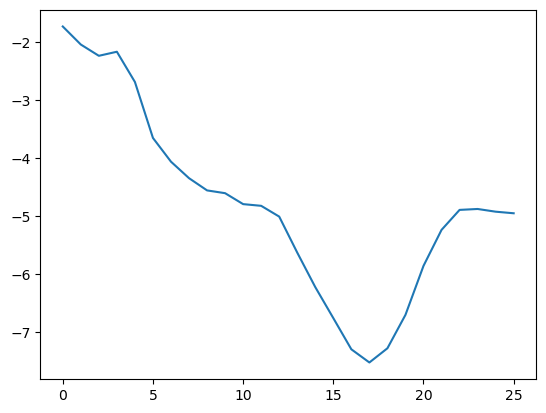

In [24]:
plt.plot(mu_all[:, 0])

In [25]:
encoder.mu_pop_mean[0]

tensor(250.2802, device='cuda:0')

In [26]:
encoder.mu_pop_var[0]

tensor(878538.3750, device='cuda:0')

In [27]:
mu_all[:,0]

array([-1.7336423, -2.044613 , -2.239048 , -2.1690154, -2.690157 ,
       -3.6550004, -4.0641875, -4.348386 , -4.5591183, -4.607058 ,
       -4.795632 , -4.8247886, -5.0105596, -5.630953 , -6.225806 ,
       -6.760141 , -7.298034 , -7.5249953, -7.2801604, -6.7042427,
       -5.859997 , -5.2397027, -4.8950667, -4.8792634, -4.9258595,
       -4.9532404], dtype=float32)

# 3. Flowed Latent

In [28]:
gc.collect()
torch.cuda.empty_cache()
dim_to_keep = 3
latent_traj_list = proj_to_latent(dset_samples_look, flow_net.to(device), 0.0, device)

100%|███████████████████████████████████████████| 30/30 [00:21<00:00,  1.43it/s]


In [29]:
lag

8

In [30]:
latent_traj_list_enc = []
for ii in range(len(dset_samples_look)):
    latent_traj_list_enc.append(recon_check_x0_allT(encoder, ii, dset_samples_look))

In [31]:
mu_traj_sim, d, L, loading, bias = latent_mu(latent_traj_list, encoder.to(device), dim_to_keep, device,
                                             fullRes = True, resid_tol=1e-15)

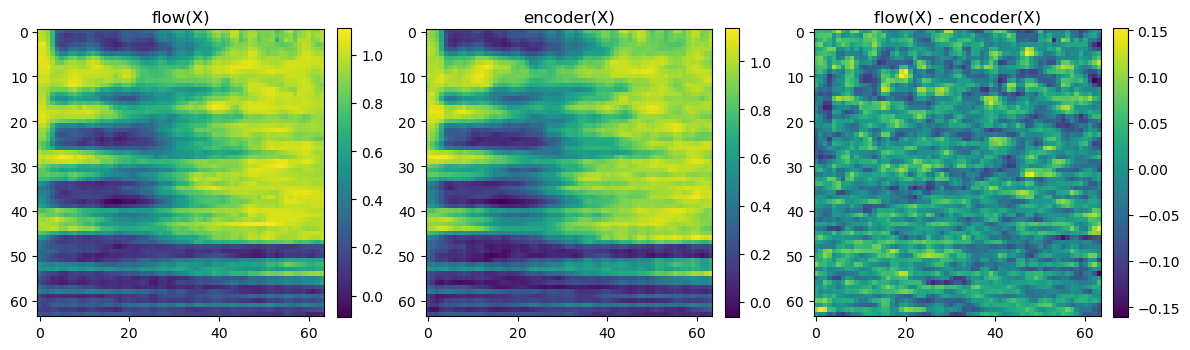

In [32]:
data_flow = [arr.reshape(arr.shape[0], C, H, W) for arr in latent_traj_list ]
data_enc = [arr.reshape(arr.shape[0], C, H, W) for arr in latent_traj_list_enc ]

T_check = 0
fig, axs = plt.subplots(1, 3, figsize=(12, 10))

im1 = axs[0].imshow(data_flow[trial_check][T_check,0])
fig.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04)  # smaller, aligned
axs[0].set_title('flow(X)')

im2 = axs[1].imshow(data_enc[trial_check][T_check,0])
fig.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04)  # smaller, aligned
axs[1].set_title('encoder(X)')

im3 = axs[2].imshow(data_flow[trial_check][T_check,0] - data_enc[trial_check][T_check,0])
fig.colorbar(im3, ax=axs[2], fraction=0.046, pad=0.04)  # smaller, aligned
axs[2].set_title('flow(X) - encoder(X)')

plt.tight_layout()
plt.show()

Text(0.5, 0.98, 'flowed latent trajc for each trial')

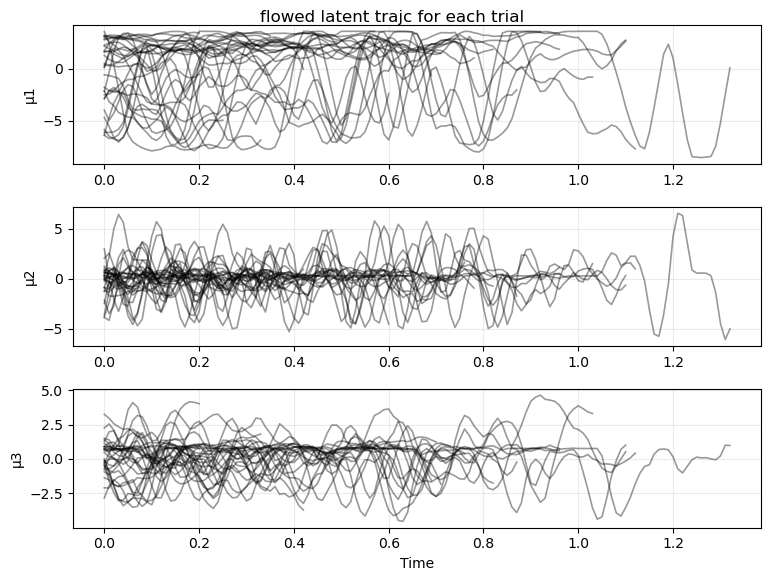

In [33]:
mu_traj_flow_np = [mu_traj_sim[j].cpu().numpy() for j in range(len(mu_traj_sim))]
plot_latent_time_series(mu_traj_flow_np, alpha = 0.4, dims=np.arange(dim_to_keep), 
                        dt=0.01, labels=None)
plt.suptitle('flowed latent trajc for each trial')

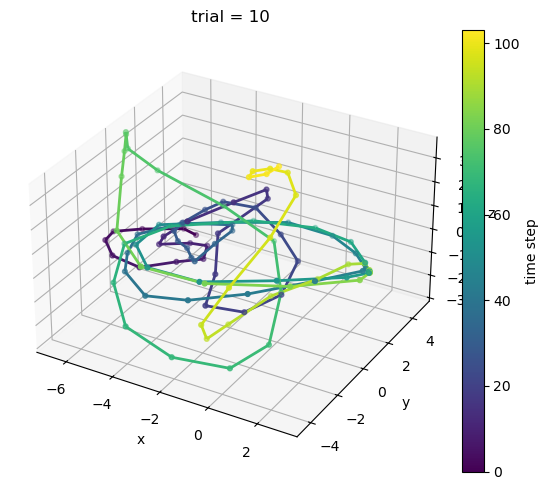

In [34]:
plot_traj_3d(mu_traj_flow_np[trial_check][:,0:3], title = 'trial = ' + str(trial_check))

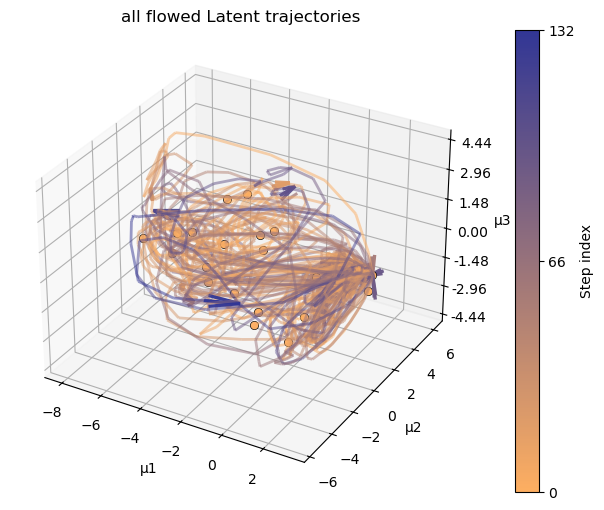

In [35]:
plot_mu_trajectories_gradient_steps_3d(
    mu_traj_flow_np,
    trial_indices=np.arange(len(mu_traj_flow_np)), 
    dims=(0,1,2),
    title="all flowed Latent trajectories",
    z_scale='auto',  # Automatically scales z to be visually comparable to x and y
    arrow_head_frac=0.08,
    arrow_length_ratio=0.9,
    elev_azim = None, # (20,45)
)

# 4. Simulated Traj

In [36]:
tau = 1.0
traj_sim_tau1_flattent, lag_cov_list = generate_traj_image_onthefly(dyn_net.to(device),
                                                                    dset_samples_look, n_step,
                                                                    tau, device, lag,
                                                                    include_x0_tau=False,
                                                                    oracle=False,
                                                                    flow_net=None,
                                                                    clamp_range=clamp_range
                                                                    )

100%|█████████████████████████████████████████| 132/132 [00:14<00:00,  8.85it/s]


In [37]:
out_imgs_tau1 = [arr.reshape(arr.shape[0], C, H, W) for arr in traj_sim_tau1_flattent]

/home/ganchao/Desktop/Velocity_Flow_Matching-global_new_param_new_pt/plot_sim_results_img_v7.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


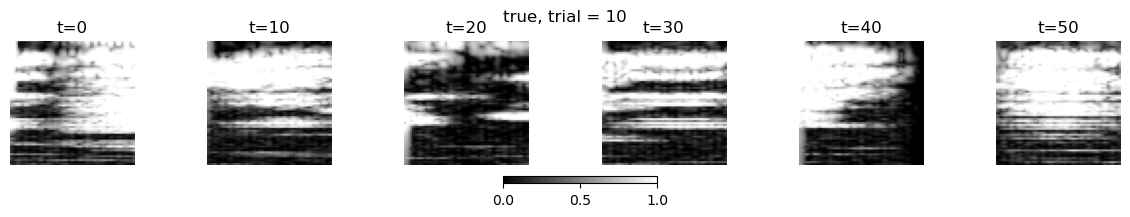

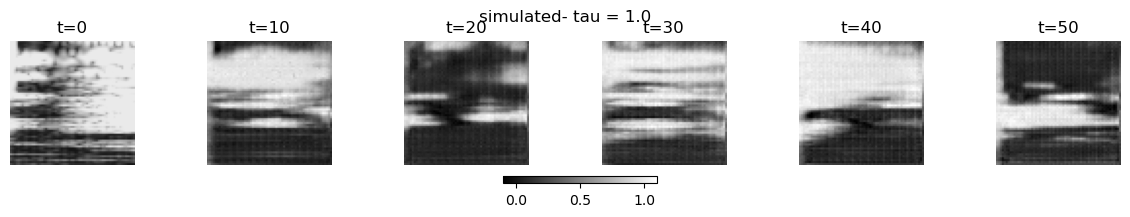

In [38]:
n_step_trial = dset_samples_look[trial_check].shape[0]
plot_tau(n_step_trial//2, out_imgs_tau1, dset_samples_look, trial_idx = trial_check, tau = 1.0)

In [39]:
out_imgs_tau0_flow_flatten = proj_to_latent(out_imgs_tau1, flow_net.to(device), 0.0, device)
out_imgs_tau0_flow = [arr.reshape(arr.shape[0], C, H, W) for arr in out_imgs_tau0_flow_flatten ]

100%|███████████████████████████████████████████| 30/30 [00:57<00:00,  1.92s/it]


In [40]:
tau = 0.0
traj_sim_tau0_flattent, _ = generate_traj_image_onthefly(dyn_net.to(device),
                                                         dset_samples_look, n_step,
                                                         tau, device, lag,
                                                         include_x0_tau=False,
                                                         oracle=False,
                                                         flow_net=flow_net.to(device),
                                                         clamp_range=clamp_range
                                                         )
out_imgs_tau0 = [arr.reshape(arr.shape[0], C, H, W) for arr in traj_sim_tau0_flattent ]

100%|█████████████████████████████████████████| 132/132 [00:12<00:00, 10.21it/s]


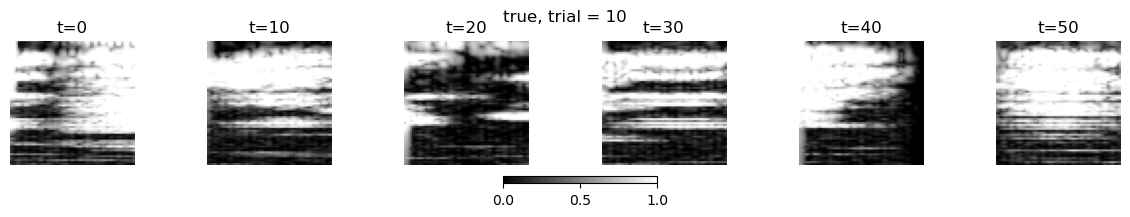

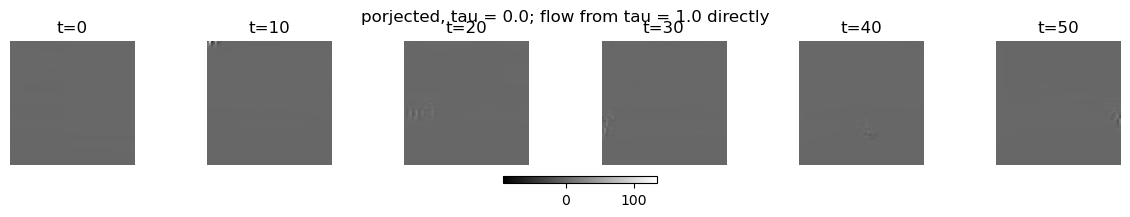

In [41]:
n_step_trial = dset_samples_look[trial_check].shape[0]
plot_tau(n_step_trial//2, out_imgs_tau0_flow, dset_samples_look,
         trial_idx = trial_check, tau = 0.0, title = 'porjected, tau = 0.0; flow from tau = 1.0 directly')

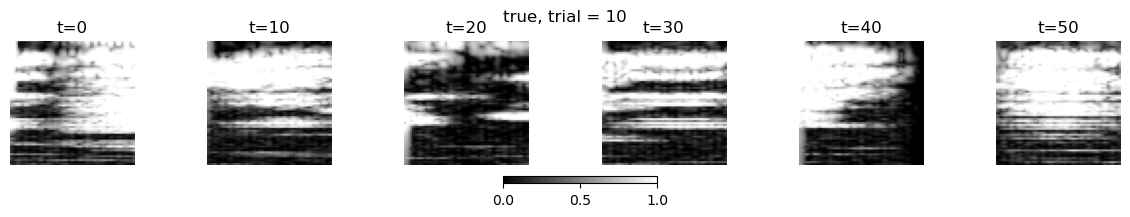

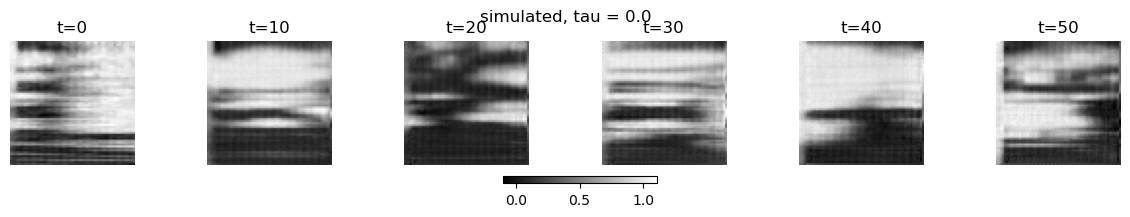

In [42]:
plot_tau(n_step_trial//2, out_imgs_tau0, dset_samples_look,
         trial_idx = trial_check, tau = 0.0, title = 'simulated, tau = 0.0')

In [43]:
dim_to_keep = 3
mu_traj_sim, d, L, loading, bias = latent_mu(traj_sim_tau0_flattent, encoder.to(device), dim_to_keep, device, fullRes = True)

Text(0.5, 0.98, 'simulated latent trajc for each trial')

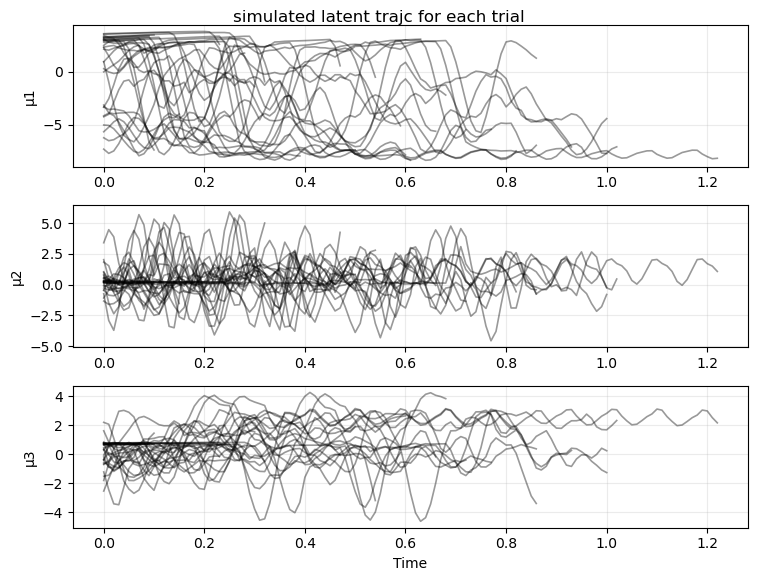

In [44]:
mu_traj_sim_np = [mu_traj_sim[j].cpu().numpy() for j in range(len(mu_traj_sim))]
mu_traj_sim_np_plot = [mu_traj_sim_np[ii][10:,:] for ii in range(len(mu_traj_sim_np))]
plot_latent_time_series(mu_traj_sim_np_plot, alpha = 0.4, dims=np.arange(dim_to_keep), 
                        dt=0.01, labels=None)
plt.suptitle('simulated latent trajc for each trial')

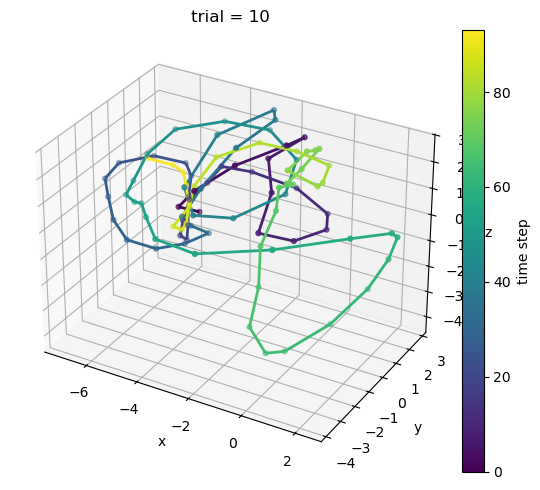

In [45]:
plot_traj_3d(mu_traj_sim_np_plot[trial_check][:,0:3], title = 'trial = ' + str(trial_check))

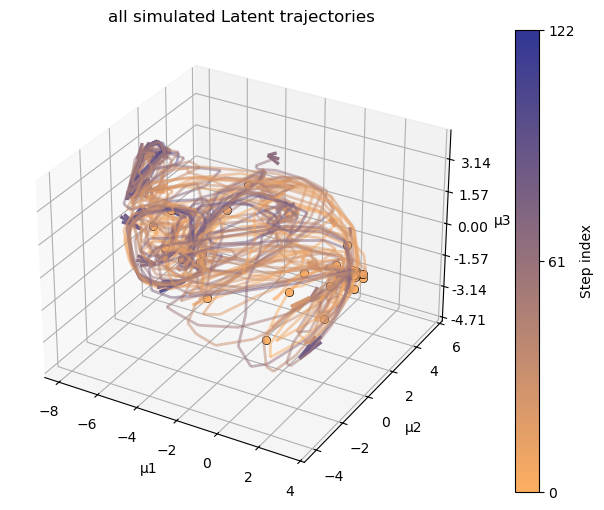

In [46]:
plot_mu_trajectories_gradient_steps_3d(
    mu_traj_sim_np_plot,
    trial_indices=np.arange(len(mu_traj_sim_np_plot)), 
    dims=(0,1,2),
    title="all simulated Latent trajectories",
    z_scale='auto',  # Automatically scales z to be visually comparable to x and y
    arrow_head_frac=0.08,
    arrow_length_ratio=0.9,
    elev_azim = None, # (20,45)
)

# 5. Flow Field

In [47]:
latent_traj_list_enc = []
for ii in range(len(dset_samples_look)):
    latent_traj_list_enc.append(recon_check_x0_allT(encoder, ii, dset_samples_look))
mu_traj_sim_enc, d, L, loading, bias = latent_mu(latent_traj_list_enc, encoder.to(device), dim_to_keep, device,
                                             fullRes = True, resid_tol=1e-15)

In [48]:
dim_to_keep = 3  # μ-dims you kept elsewhere
mu_pts_encoder, v_mu_encoder = compute_mu_velocity_field(
    latent_traj_list=latent_traj_list_enc,
    dyn_net=dyn_net,
    encoder=encoder,
    device=device,
    dim_preserve=dim_to_keep,
    lag=lag,
    t_plot=0.0,
)

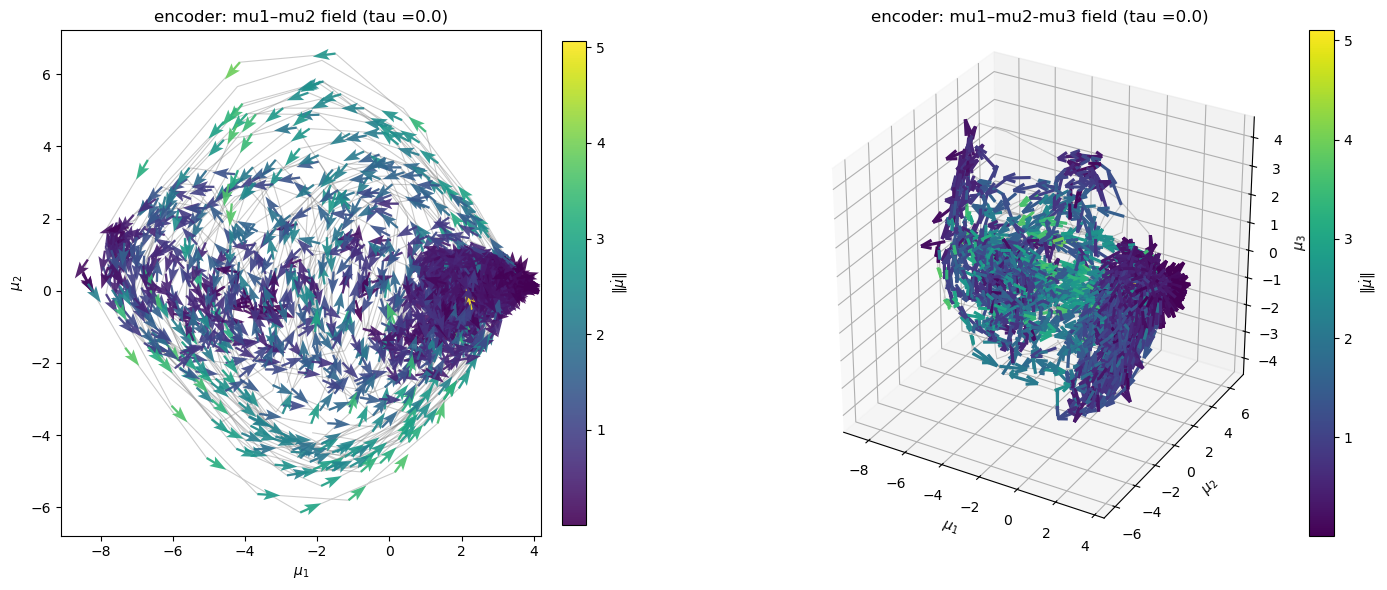

In [49]:
plot_mu_velocity_panel(mu_pts_encoder, v_mu_encoder,
                       trajectories=mu_traj_sim_enc,
                       title_2d = "encoder: mu1–mu2 field (tau =0.0)",
                       title_3d = "encoder: mu1–mu2-mu3 field (tau =0.0)",
                       arrow_frac_2d=0.05,
                       arrow_size_2d=1.2,
                       linewidth_2d=1.5,
                       
                       arrow_frac_3d=0.1,
                       arrow_size_3d=1.5,
                       linewidth_3d=1.5,
                       base_arrow_length_ratio_3d=0.3,
                       )

100%|███████████████████████████████████████████| 30/30 [00:20<00:00,  1.46it/s]


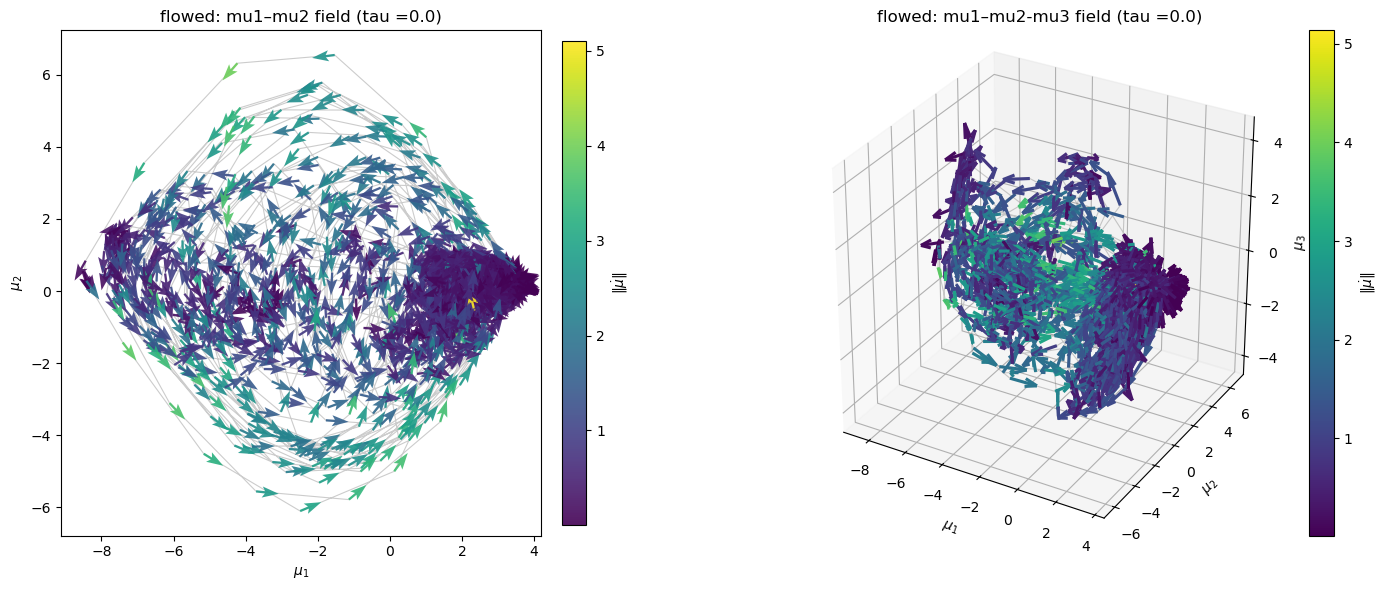

In [50]:
latent_traj_list = proj_to_latent(dset_samples_look, flow_net.to(device), 0.0, device)
mu_traj_sim, d, L, loading, bias = latent_mu(latent_traj_list, encoder.to(device), dim_to_keep, device,
                                             fullRes = True, resid_tol=1e-15)

dim_to_keep = 3  # μ-dims you kept elsewhere
mu_pts_flow, v_mu_flow = compute_mu_velocity_field(
    latent_traj_list=latent_traj_list,
    dyn_net=dyn_net,
    encoder=encoder,
    device=device,
    dim_preserve=dim_to_keep,
    lag=lag,
    t_plot=0.0,
)

plot_mu_velocity_panel(mu_pts_flow, v_mu_flow,
                       trajectories=[mu_pts_flow], # mu_traj_sim
                       title_2d = "flowed: mu1–mu2 field (tau =0.0)",
                       title_3d = "flowed: mu1–mu2-mu3 field (tau =0.0)",
                       arrow_frac_2d=0.05,
                       arrow_size_2d=1.2,
                       linewidth_2d=1.5,
                       
                       arrow_frac_3d=0.1,
                       arrow_size_3d=1.5,
                       linewidth_3d=1.5,
                       base_arrow_length_ratio_3d=0.3,
                       )

In [51]:
def calculate_mean_trajectory(traj_list):
    if not traj_list:
        return None
    min_len = min(arr.shape[0] for arr in traj_list)
    print(f"Minimum length found across trials: {min_len}")
    truncated_trajs = [arr[:min_len, :] for arr in traj_list]
    stacked_trajs = np.array(truncated_trajs)
    mean_traj = np.mean(stacked_trajs, axis=0)

    return mean_traj
mean_traj = calculate_mean_trajectory(mu_traj_flow_np)

Minimum length found across trials: 20


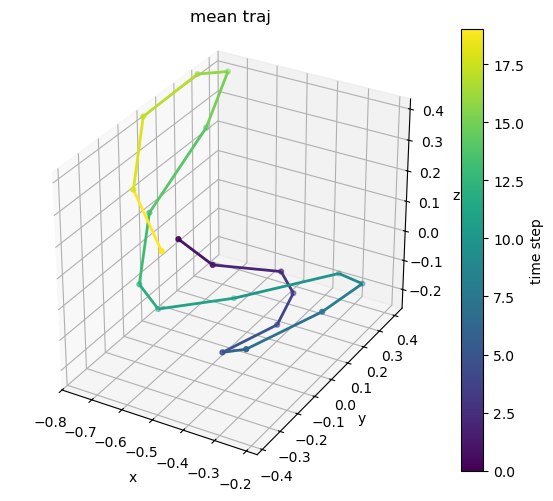

In [52]:
plot_traj_3d(mean_traj, title = 'mean traj')